# TEMPLE (Temporal Energy Model for Pricing and Linear Evaluation) ML PROJECT

### End to End lifecycle of ML project ♻️
° Understanding the problem statement

° Data collection

° Data checks to perform

° Exploratory data analysis

° Data Pre-processing

° Model Training

° Choosing the right/best model

### a) Problem Statement
Energy pricing is a dynamic and complex process influenced by temporal factors such as seasons, years, and varying consumption scales across different consumer categories. Stakeholders often face challenges in understanding how these factors collectively impact the average cost of energy (electricity and gas). Without clear insights, it becomes difficult to forecast pricing trends, optimize energy distribution, and support strategic decision-making.

### b)Aim

The aim of TEMPLE is to develop a simple yet effective linear regression model to predict average electricity pricing based on temporal and categorical energy consumption data. By leveraging historical pricing data and exploring the temporal trends, the project seeks to:

	•	Identify key drivers influencing energy prices over time.

	•	Provide a transparent and interpretable tool for pricing evaluation to inform strategic energy decisions.

### c) Solution

TEMPLE employs supervised learning techniques, specifically linear regression, to analyze temporal energy pricing data. The project creates a predictive model that estimates the Electricity: Average (Pence per kWh) based on factors such as year, quarter, and pricing categories across different consumer scales. This approach not only forecasts average energy prices but also offers actionable insights into how temporal and category-specific variables impact costs.

By simplifying the complexities of energy pricing trends, TEMPLE aims to support stakeholders in making data-driven decisions to improve energy market efficiency.


### 1) Data Collection
 Dataset Source: https://www.gov.uk/government/statistical-data-sets/gas-and-electricity-prices-in-the-non-domestic-sector
 
 Data consists of 16 columns and 82 rows.

### 2) Importing locally downloaded data and Reqired packages

***Required libraries***

° Pandas

° numpy

° seaborn

° matplotlib

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Importing data
file_path = "/Users/justicesmacboookair/Documents/Data-science/TEMPLE/src/research/data/temple_raw.xlsx"
excel_data = pd.ExcelFile(file_path)
excel_data.sheet_names

['Cover sheet',
 'Contents',
 '3.4.1 (excl CCL)',
 '3.4.1 (Annual excl CCL)',
 '3.4.2 (incl CCL)',
 '3.4.2 (Annual inc CCL)',
 'Notes',
 'Charts',
 'chart_data',
 'CCL Paid']

In [3]:
# Load data from the specified sheet "3.4.2 (incl CCL)" and preview the first few rows
raw_data = pd.read_excel(excel_data, sheet_name='3.4.2 (incl CCL)', skiprows=6, nrows=83)
raw_data.head()

,Year,Quarter,Electricity: Very Small (Pence per kWh),Electricity: Small (Pence per kWh),Electricity: Small/Medium (Pence per kWh),Electricity: Medium (Pence per kWh),Electricity: Large (Pence per kWh),Electricity: Very Large (Pence per kWh),Electricity: Extra Large (Pence per kWh),Electricity: Average (Pence per kWh),Gas: Very Small (Pence per kWh),Gas: Small (Pence per kWh),Gas: Medium (Pence per kWh),Gas: Large (Pence per kWh),Gas: Very Large (Pence per kWh),Gas: Average (Pence per kWh)
0,2004,1st,6.041900,5.491762,4.139750,3.639109,3.376946,2.975759,NaN,4.015,1.613505,1.406366,1.163652,1.040894,0.877579,1.251000
1,2004,2nd,6.128515,5.310131,4.213574,3.653105,3.297979,2.858516,NaN,3.887,1.466271,1.304053,1.262996,1.034469,1.087342,1.225000
2,2004,3rd,6.392726,4.763896,3.928002,3.732960,3.676800,3.113938,NaN,3.946,1.688511,1.513226,1.214925,0.906780,0.984872,1.209000
3,2004,4th,6.442553,5.724362,4.898325,4.282188,4.186195,3.814257,NaN,4.742,1.485573,1.394492,1.339390,1.200072,1.036643,1.305574
4,2005,1st,6.610770,5.930425,5.273539,4.563788,4.303348,3.841138,NaN,4.845,1.834352,1.725252,1.596385,1.437451,1.287418,1.580000


### 3) DATA UNDERSTANDING

In [4]:
raw_data.shape

(82, 16)

In [5]:
raw_data.columns

Index(['Year', 'Quarter', 'Electricity: Very Small (Pence per kWh)',
       'Electricity: Small (Pence per kWh)',
       'Electricity: Small/Medium (Pence per kWh)',
       'Electricity: Medium (Pence per kWh)',
       'Electricity: Large (Pence per kWh)',
       'Electricity: Very Large (Pence per kWh)',
       'Electricity: Extra Large (Pence per kWh)',
       'Electricity: Average (Pence per kWh)',
       'Gas: Very Small (Pence per kWh)', 'Gas: Small (Pence per kWh)',
       'Gas: Medium (Pence per kWh)', 'Gas: Large (Pence per kWh)',
       'Gas: Very Large (Pence per kWh)', 'Gas: Average (Pence per kWh)'],
      dtype='object')

In [6]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Year                                       82 non-null     int64  
 1   Quarter                                    82 non-null     object 
 2   Electricity: Very Small (Pence per kWh)    82 non-null     float64
 3   Electricity: Small (Pence per kWh)         82 non-null     float64
 4   Electricity: Small/Medium (Pence per kWh)  82 non-null     float64
 5   Electricity: Medium (Pence per kWh)        82 non-null     float64
 6   Electricity: Large (Pence per kWh)         82 non-null     float64
 7   Electricity: Very Large (Pence per kWh)    82 non-null     float64
 8   Electricity: Extra Large (Pence per kWh)   70 non-null     float64
 9   Electricity: Average (Pence per kWh)       82 non-null     float64
 10  Gas: Very Small (Pence per k

In [7]:
raw_data.describe()

,Year,Electricity: Very Small (Pence per kWh),Electricity: Small (Pence per kWh),Electricity: Small/Medium (Pence per kWh),Electricity: Medium (Pence per kWh),Electricity: Large (Pence per kWh),Electricity: Very Large (Pence per kWh),Electricity: Extra Large (Pence per kWh),Electricity: Average (Pence per kWh),Gas: Very Small (Pence per kWh),Gas: Small (Pence per kWh),Gas: Medium (Pence per kWh),Gas: Large (Pence per kWh),Gas: Very Large (Pence per kWh),Gas: Average (Pence per kWh)
count,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,70.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,2013.756098,14.540744,13.080880,12.180152,11.079017,10.609586,10.069059,10.699458,11.416592,4.403826,2.987706,2.662213,2.333606,2.161893,2.808830
std,5.957796,6.369036,6.633007,6.910407,6.307696,5.928885,5.202173,4.957989,5.776628,2.111903,1.163077,1.113239,1.155719,1.253556,1.294928
min,2004.000000,6.041900,4.763896,3.928002,3.639109,3.297979,2.858516,4.306788,3.887000,1.466271,1.304053,1.163652,0.906780,0.877579,1.209000
25%,2009.000000,11.637226,10.006634,8.462806,7.500057,6.894412,6.897821,7.280578,8.423066,3.258971,2.394414,2.076264,1.702018,1.447987,2.163486
50%,2014.000000,12.950281,11.738664,10.505128,9.553247,9.423591,9.296985,9.157840,10.181029,4.092152,2.694764,2.367633,1.970357,1.778514,2.472274
75%,2019.000000,16.415819,14.645022,13.178909,12.278249,11.466632,10.718925,11.827197,12.378447,4.822428,3.097945,2.776353,2.406744,2.130723,2.892369
max,2024.000000,34.013852,34.571636,32.862863,30.974945,29.377203,24.016958,23.268304,28.388322,12.022877,7.167245,6.962740,6.527239,6.365690,7.183172


***Insights💡***

I have observed:

**Missing Values**

° “Electricity: Extra Large (Pence per kWh)” has 12 missing values.

**Electricity Prices Analysis**

° The “Very Small” electricity category has the highest mean (2013.76 pence per kWh).

° Electricity prices gradually decrease as the size category increases, with “Extra Large” having the lowest mean (10.07 pence per kWh).

° There is considerable variation in electricity prices, with standard deviations ranging from 5.2 to 6.9 across different categories.

° The highest electricity price (“Very Small”) is significantly higher than the lowest (“Extra Large”), indicating a steep drop in prices as the consumer size category increases.

**Min and Max Electricity Prices**

° “Very Small” electricity price reaches a maximum of 34.01 pence per kWh.

° “Extra Large” electricity price reaches a maximum of 24.02 pence per kWh.

**General Trend**

° Electricity prices decrease as consumer size increases, potentially due to economies of scale or pricing models favoring larger consumers.

**Outliers**

° There appear to be outliers, especially in the “Very Small” electricity category, where prices can reach notably high values (e.g., max electricity price of 34.01 pence per kWh).

**Target Variable**

° Electricity: Average (Pence per kWh) is the primary target variable for prediction.

**Data Preprocessing Decision**

° Gas-related columns will be dropped, as this project focuses solely on electricity pricing.


### 4) Data checks to perform

° Check missing values

° Check duplicated values

° Check data types

° Check statistics of dataset

° Check various categories present in the different categorical column

**4.1) Checking duplicated values**

In [8]:
raw_data.duplicated().sum()

np.int64(0)

***Insights💡***

° There are no duplicate values in this data set

**4.2) Checking missing values**

In [9]:
raw_data.isnull().sum()

Year                                          0
Quarter                                       0
Electricity: Very Small (Pence per kWh)       0
Electricity: Small (Pence per kWh)            0
Electricity: Small/Medium (Pence per kWh)     0
Electricity: Medium (Pence per kWh)           0
Electricity: Large (Pence per kWh)            0
Electricity: Very Large (Pence per kWh)       0
Electricity: Extra Large (Pence per kWh)     12
Electricity: Average (Pence per kWh)          0
Gas: Very Small (Pence per kWh)               0
Gas: Small (Pence per kWh)                    0
Gas: Medium (Pence per kWh)                   0
Gas: Large (Pence per kWh)                    0
Gas: Very Large (Pence per kWh)               0
Gas: Average (Pence per kWh)                  0
dtype: int64

***Insights💡***

° There are 12 missing valus in the Electricity: Extra Large (Pence per kWh) coloumn

**4.3) Checking data types**

In [10]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 16 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Year                                       82 non-null     int64  
 1   Quarter                                    82 non-null     object 
 2   Electricity: Very Small (Pence per kWh)    82 non-null     float64
 3   Electricity: Small (Pence per kWh)         82 non-null     float64
 4   Electricity: Small/Medium (Pence per kWh)  82 non-null     float64
 5   Electricity: Medium (Pence per kWh)        82 non-null     float64
 6   Electricity: Large (Pence per kWh)         82 non-null     float64
 7   Electricity: Very Large (Pence per kWh)    82 non-null     float64
 8   Electricity: Extra Large (Pence per kWh)   70 non-null     float64
 9   Electricity: Average (Pence per kWh)       82 non-null     float64
 10  Gas: Very Small (Pence per k

**4.4) Checking unique values in each column**

In [11]:
raw_data.nunique()

Year                                         21
Quarter                                       4
Electricity: Very Small (Pence per kWh)      82
Electricity: Small (Pence per kWh)           82
Electricity: Small/Medium (Pence per kWh)    82
Electricity: Medium (Pence per kWh)          82
Electricity: Large (Pence per kWh)           82
Electricity: Very Large (Pence per kWh)      82
Electricity: Extra Large (Pence per kWh)     70
Electricity: Average (Pence per kWh)         82
Gas: Very Small (Pence per kWh)              82
Gas: Small (Pence per kWh)                   82
Gas: Medium (Pence per kWh)                  82
Gas: Large (Pence per kWh)                   82
Gas: Very Large (Pence per kWh)              82
Gas: Average (Pence per kWh)                 82
dtype: int64

In [12]:
print(raw_data['Year'].unique())

[2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024]


In [13]:
print(raw_data['Quarter'].unique())

['1st' '2nd' '3rd' '4th']


In [14]:
# Check for NaN values in the "Electricity: Extra Large (Pence per kWh)" column
nan_values = raw_data[raw_data["Electricity: Extra Large (Pence per kWh)"].isna()]

# Print the rows where the value is NaN
nan_values

,Year,Quarter,Electricity: Very Small (Pence per kWh),Electricity: Small (Pence per kWh),Electricity: Small/Medium (Pence per kWh),Electricity: Medium (Pence per kWh),Electricity: Large (Pence per kWh),Electricity: Very Large (Pence per kWh),Electricity: Extra Large (Pence per kWh),Electricity: Average (Pence per kWh),Gas: Very Small (Pence per kWh),Gas: Small (Pence per kWh),Gas: Medium (Pence per kWh),Gas: Large (Pence per kWh),Gas: Very Large (Pence per kWh),Gas: Average (Pence per kWh)
0,2004,1st,6.041900,5.491762,4.139750,3.639109,3.376946,2.975759,NaN,4.015000,1.613505,1.406366,1.163652,1.040894,0.877579,1.251000
1,2004,2nd,6.128515,5.310131,4.213574,3.653105,3.297979,2.858516,NaN,3.887000,1.466271,1.304053,1.262996,1.034469,1.087342,1.225000
2,2004,3rd,6.392726,4.763896,3.928002,3.732960,3.676800,3.113938,NaN,3.946000,1.688511,1.513226,1.214925,0.906780,0.984872,1.209000
3,2004,4th,6.442553,5.724362,4.898325,4.282188,4.186195,3.814257,NaN,4.742000,1.485573,1.394492,1.339390,1.200072,1.036643,1.305574
4,2005,1st,6.610770,5.930425,5.273539,4.563788,4.303348,3.841138,NaN,4.845000,1.834352,1.725252,1.596385,1.437451,1.287418,1.580000
5,2005,2nd,6.884462,5.952780,5.284277,4.570169,4.282619,3.890400,NaN,4.888000,1.874578,1.885010,1.770310,1.413253,1.286272,1.655000
6,2005,3rd,7.095552,6.119670,5.454087,4.676087,4.294044,4.101912,NaN,5.020000,1.866497,1.805903,1.587765,1.312448,1.169644,1.511000
7,2005,4th,7.296008,6.685367,6.441897,5.852009,5.254934,4.822106,NaN,5.814000,2.063000,2.083000,1.986000,1.830368,1.985114,2.039000
8,2006,1st,7.609818,6.890000,7.028251,6.299043,6.104012,5.321902,NaN,6.408109,2.366942,2.398339,2.374864,2.378582,2.065847,2.337000
9,2006,2nd,8.164469,7.037213,6.851053,6.233031,5.881097,5.330767,NaN,6.424517,2.280729,2.234614,2.036887,1.801633,1.445741,1.936000


***Insights💡***

° There are 4 unique values in 'Quarter' column, 21 in 'year' column, and 70 in 'Electricity: Extra Large (Pence per kWh)' column

Possible Causes of 12 missing values 'Electricity: Extra Large (Pence per kWh)' column:

a) Identical Prices Across Different Time Periods or Categories

	•	Some electricity prices might be the same across different years or quarters.

b) Data Aggregation or Rounding

	•	If prices were rounded to fewer decimal places, multiple records could have the same values.

c) Missing Data and Missing Years:
	•	Given that the describe() summary shows a minimum year of 2004 but no unique years between 2004–2006, it’s likely that data from 2004 to 2006 may be underrepresented or missing in the dataset.


**Decision:** Drop the repeated values

**4.5) Checking dataset statistics**

In [15]:
raw_data.describe()

,Year,Electricity: Very Small (Pence per kWh),Electricity: Small (Pence per kWh),Electricity: Small/Medium (Pence per kWh),Electricity: Medium (Pence per kWh),Electricity: Large (Pence per kWh),Electricity: Very Large (Pence per kWh),Electricity: Extra Large (Pence per kWh),Electricity: Average (Pence per kWh),Gas: Very Small (Pence per kWh),Gas: Small (Pence per kWh),Gas: Medium (Pence per kWh),Gas: Large (Pence per kWh),Gas: Very Large (Pence per kWh),Gas: Average (Pence per kWh)
count,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,70.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,2013.756098,14.540744,13.080880,12.180152,11.079017,10.609586,10.069059,10.699458,11.416592,4.403826,2.987706,2.662213,2.333606,2.161893,2.808830
std,5.957796,6.369036,6.633007,6.910407,6.307696,5.928885,5.202173,4.957989,5.776628,2.111903,1.163077,1.113239,1.155719,1.253556,1.294928
min,2004.000000,6.041900,4.763896,3.928002,3.639109,3.297979,2.858516,4.306788,3.887000,1.466271,1.304053,1.163652,0.906780,0.877579,1.209000
25%,2009.000000,11.637226,10.006634,8.462806,7.500057,6.894412,6.897821,7.280578,8.423066,3.258971,2.394414,2.076264,1.702018,1.447987,2.163486
50%,2014.000000,12.950281,11.738664,10.505128,9.553247,9.423591,9.296985,9.157840,10.181029,4.092152,2.694764,2.367633,1.970357,1.778514,2.472274
75%,2019.000000,16.415819,14.645022,13.178909,12.278249,11.466632,10.718925,11.827197,12.378447,4.822428,3.097945,2.776353,2.406744,2.130723,2.892369
max,2024.000000,34.013852,34.571636,32.862863,30.974945,29.377203,24.016958,23.268304,28.388322,12.022877,7.167245,6.962740,6.527239,6.365690,7.183172


### 5) Data cleaning


In [16]:
raw_data = raw_data.dropna()

In [17]:
raw_data.isnull().sum()

Year                                         0
Quarter                                      0
Electricity: Very Small (Pence per kWh)      0
Electricity: Small (Pence per kWh)           0
Electricity: Small/Medium (Pence per kWh)    0
Electricity: Medium (Pence per kWh)          0
Electricity: Large (Pence per kWh)           0
Electricity: Very Large (Pence per kWh)      0
Electricity: Extra Large (Pence per kWh)     0
Electricity: Average (Pence per kWh)         0
Gas: Very Small (Pence per kWh)              0
Gas: Small (Pence per kWh)                   0
Gas: Medium (Pence per kWh)                  0
Gas: Large (Pence per kWh)                   0
Gas: Very Large (Pence per kWh)              0
Gas: Average (Pence per kWh)                 0
dtype: int64

In [18]:
# Dropping all columns irrelevant to Project - Temple
raw_data = raw_data.drop(columns=[
    'Gas: Very Small (Pence per kWh)', 
    'Gas: Small (Pence per kWh)', 
    'Gas: Medium (Pence per kWh)', 
    'Gas: Large (Pence per kWh)', 
    'Gas: Very Large (Pence per kWh)', 
    'Gas: Average (Pence per kWh)'
])

In [19]:
raw_data.info()
raw_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 12 to 81
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Year                                       70 non-null     int64  
 1   Quarter                                    70 non-null     object 
 2   Electricity: Very Small (Pence per kWh)    70 non-null     float64
 3   Electricity: Small (Pence per kWh)         70 non-null     float64
 4   Electricity: Small/Medium (Pence per kWh)  70 non-null     float64
 5   Electricity: Medium (Pence per kWh)        70 non-null     float64
 6   Electricity: Large (Pence per kWh)         70 non-null     float64
 7   Electricity: Very Large (Pence per kWh)    70 non-null     float64
 8   Electricity: Extra Large (Pence per kWh)   70 non-null     float64
 9   Electricity: Average (Pence per kWh)       70 non-null     float64
dtypes: float64(8), int64(1), object(

,Year,Quarter,Electricity: Very Small (Pence per kWh),Electricity: Small (Pence per kWh),Electricity: Small/Medium (Pence per kWh),Electricity: Medium (Pence per kWh),Electricity: Large (Pence per kWh),Electricity: Very Large (Pence per kWh),Electricity: Extra Large (Pence per kWh),Electricity: Average (Pence per kWh)
12,2007,1st,9.531999,8.302909,8.048118,7.257151,6.771136,6.820582,6.438687,7.637417
13,2007,2nd,9.845438,7.647641,6.913110,6.522139,5.928171,5.774705,4.859447,6.748888
14,2007,3rd,9.923440,8.335395,7.509659,6.525570,6.087500,5.784247,4.306788,6.880579
15,2007,4th,9.933320,8.437592,7.453594,6.574385,6.184248,5.956329,5.476230,7.117072
16,2008,1st,10.020676,8.604631,7.549362,6.615001,6.437835,6.608856,5.766387,7.363354


### 6) Exploratory Data Analysis

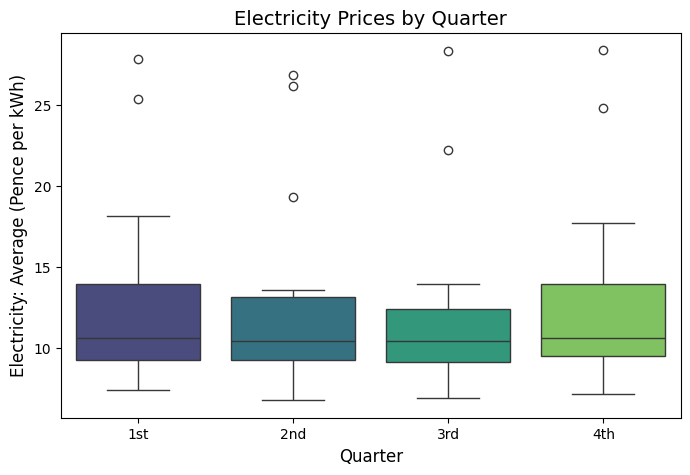

In [20]:
# Visualization: Box plot to show variation of electricity prices across quarters
plt.figure(figsize=(8, 5))
sns.boxplot(x="Quarter", y="Electricity: Average (Pence per kWh)", data=raw_data, hue="Quarter", palette="viridis", dodge=False)
plt.title("Electricity Prices by Quarter", fontsize=14)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Electricity: Average (Pence per kWh)", fontsize=12)
plt.legend([],[], frameon=False)  # Remove legend for cleaner plot
plt.show()

***6.2) Bivariate Analysis***

***6.3) Comparative Analysis***

In [21]:
# Descriptive statistics grouped by quarter
quarter_stats = raw_data.groupby("Quarter")["Electricity: Average (Pence per kWh)"].describe()
print(quarter_stats)

         count       mean       std       min       25%        50%        75%  \
Quarter                                                                         
1st       18.0  12.634462  5.771441  7.363354  9.250616  10.580201  13.951734   
2nd       18.0  12.470649  5.837876  6.748888  9.226587  10.391831  13.117668   
3rd       17.0  11.943372  5.440133  6.880579  9.132241  10.386669  12.398951   
4th       17.0  12.784171  5.812041  7.117072  9.456606  10.594841  13.956106   

               max  
Quarter             
1st      27.819619  
2nd      26.877803  
3rd      28.324525  
4th      28.388322  


In [22]:
# Group by Year and calculate mean electricity price
yearly_stats = raw_data.groupby("Year")["Electricity: Average (Pence per kWh)"].describe()

# Print summary statistics
print(yearly_stats)

      count       mean       std        min        25%        50%        75%  \
Year                                                                           
2007    4.0   7.095989  0.391778   6.748888   6.847656   6.998825   7.247158   
2008    4.0   8.219747  1.037994   7.363354   7.623909   7.902296   8.498134   
2009    4.0   9.191339  0.257200   8.854945   9.062917   9.239466   9.367888   
2010    4.0   8.524203  0.163551   8.424468   8.427128   8.452759   8.549834   
2011    4.0   8.556738  0.295129   8.368059   8.408964   8.430907   8.578681   
2012    4.0   9.243669  0.145788   9.141190   9.154015   9.188440   9.278095   
2013    4.0   9.791868  0.256322   9.571757   9.669957   9.716857   9.838769   
2014    4.0  10.272294  0.135461  10.136276  10.184111  10.253519  10.341702   
2015    4.0  10.529109  0.088919  10.448681  10.454460  10.525614  10.600263   
2016    4.0  10.533866  0.246731  10.327276  10.371820  10.465272  10.627317   
2017    4.0  10.912858  0.242332  10.738

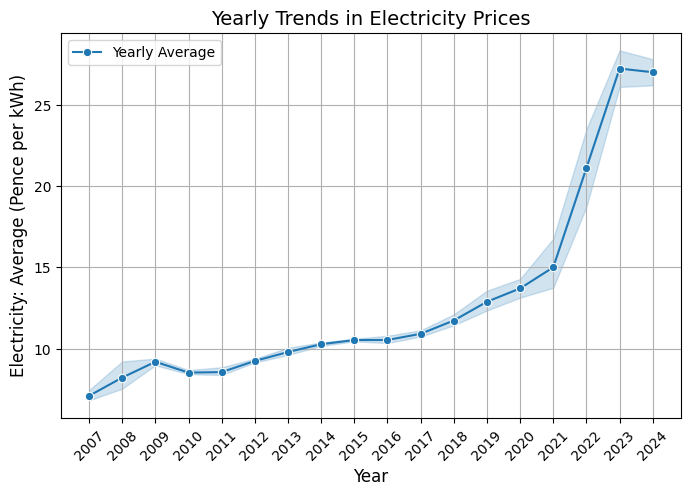

In [23]:
'''
REVIEW THIS WELL SINCE YOUVE CHAGED DATES TO CATEGORICAL, SHOWUL YOU JUST MAKE THIS STRAIGHTON DATE COLUMN BYADDING QUARTED AND YEAR AS 1 COLUMN OR LEAVE AS IS
'''
# Convert the Year column to a categorical type
raw_data['Year'] = raw_data['Year'].astype(str)

# Visualization: Line plot for yearly trends
plt.figure(figsize=(8, 5))
sns.lineplot(x="Year", y="Electricity: Average (Pence per kWh)", data=raw_data, marker="o", label="Yearly Average")
plt.title("Yearly Trends in Electricity Prices", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Electricity: Average (Pence per kWh)", fontsize=12)
plt.legend()
plt.grid(True)

# Rotate the x-axis labels for better visibility
plt.xticks(rotation=45)
plt.show()

In [24]:
raw_data.info()
raw_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 12 to 81
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Year                                       70 non-null     object 
 1   Quarter                                    70 non-null     object 
 2   Electricity: Very Small (Pence per kWh)    70 non-null     float64
 3   Electricity: Small (Pence per kWh)         70 non-null     float64
 4   Electricity: Small/Medium (Pence per kWh)  70 non-null     float64
 5   Electricity: Medium (Pence per kWh)        70 non-null     float64
 6   Electricity: Large (Pence per kWh)         70 non-null     float64
 7   Electricity: Very Large (Pence per kWh)    70 non-null     float64
 8   Electricity: Extra Large (Pence per kWh)   70 non-null     float64
 9   Electricity: Average (Pence per kWh)       70 non-null     float64
dtypes: float64(8), object(2)
memory 

,Year,Quarter,Electricity: Very Small (Pence per kWh),Electricity: Small (Pence per kWh),Electricity: Small/Medium (Pence per kWh),Electricity: Medium (Pence per kWh),Electricity: Large (Pence per kWh),Electricity: Very Large (Pence per kWh),Electricity: Extra Large (Pence per kWh),Electricity: Average (Pence per kWh)
12,2007,1st,9.531999,8.302909,8.048118,7.257151,6.771136,6.820582,6.438687,7.637417
13,2007,2nd,9.845438,7.647641,6.913110,6.522139,5.928171,5.774705,4.859447,6.748888
14,2007,3rd,9.923440,8.335395,7.509659,6.525570,6.087500,5.784247,4.306788,6.880579
15,2007,4th,9.933320,8.437592,7.453594,6.574385,6.184248,5.956329,5.476230,7.117072
16,2008,1st,10.020676,8.604631,7.549362,6.615001,6.437835,6.608856,5.766387,7.363354


# FEATURE ENGINEERING

In [25]:
'''
Quarter as a Numeric Feature: Convert the “Quarter” column to numeric values (1st → 1, 2nd → 2, etc.). 
This will help capture the impact of different quarters on electricity prices. 
You can also consider encoding “Quarter” as a cyclic feature if you expect it to have seasonal effects (e.g., Winter prices might differ from Summer).
'''
raw_data['Quarter'] = raw_data['Quarter'].map({'1st': 1, '2nd': 2, '3rd': 3, '4th': 4})

In [26]:
'''Aggregating Average Price Across Categories: This can capture general pricing trends across all categories. 
It’s a good indicator of the overall electricity pricing environment.'''

raw_data['Avg_Electricity_Price'] = raw_data[['Electricity: Very Small (Pence per kWh)', 
                                              'Electricity: Small (Pence per kWh)', 
                                              'Electricity: Small/Medium (Pence per kWh)', 
                                              'Electricity: Medium (Pence per kWh)', 
                                              'Electricity: Large (Pence per kWh)', 
                                              'Electricity: Very Large (Pence per kWh)', 
                                              'Electricity: Extra Large (Pence per kWh)']].mean(axis=1)

In [27]:
raw_data.head()

,Year,Quarter,Electricity: Very Small (Pence per kWh),Electricity: Small (Pence per kWh),Electricity: Small/Medium (Pence per kWh),Electricity: Medium (Pence per kWh),Electricity: Large (Pence per kWh),Electricity: Very Large (Pence per kWh),Electricity: Extra Large (Pence per kWh),Electricity: Average (Pence per kWh),Avg_Electricity_Price
12,2007,1,9.531999,8.302909,8.048118,7.257151,6.771136,6.820582,6.438687,7.637417,7.595798
13,2007,2,9.845438,7.647641,6.913110,6.522139,5.928171,5.774705,4.859447,6.748888,6.784379
14,2007,3,9.923440,8.335395,7.509659,6.525570,6.087500,5.784247,4.306788,6.880579,6.924657
15,2007,4,9.933320,8.437592,7.453594,6.574385,6.184248,5.956329,5.476230,7.117072,7.145100
16,2008,1,10.020676,8.604631,7.549362,6.615001,6.437835,6.608856,5.766387,7.363354,7.371821


In [28]:
# updating numerical & categorical data
numeric_data = raw_data.select_dtypes(include=["float64", "int64"])
numeric_data

,Quarter,Electricity: Very Small (Pence per kWh),Electricity: Small (Pence per kWh),Electricity: Small/Medium (Pence per kWh),Electricity: Medium (Pence per kWh),Electricity: Large (Pence per kWh),Electricity: Very Large (Pence per kWh),Electricity: Extra Large (Pence per kWh),Electricity: Average (Pence per kWh),Avg_Electricity_Price
12,1,9.531999,8.302909,8.048118,7.257151,6.771136,6.820582,6.438687,7.637417,7.595798
13,2,9.845438,7.647641,6.913110,6.522139,5.928171,5.774705,4.859447,6.748888,6.784379
14,3,9.923440,8.335395,7.509659,6.525570,6.087500,5.784247,4.306788,6.880579,6.924657
15,4,9.933320,8.437592,7.453594,6.574385,6.184248,5.956329,5.476230,7.117072,7.145100
16,1,10.020676,8.604631,7.549362,6.615001,6.437835,6.608856,5.766387,7.363354,7.371821
...,...,...,...,...,...,...,...,...,...,...
77,2,34.013852,33.289994,32.811637,29.302016,26.704029,22.558242,20.880573,26.877803,28.508620
78,3,32.487779,34.350643,32.862863,30.974945,29.377203,23.391796,23.101722,28.324525,29.506707
79,4,32.206682,34.571636,32.539440,30.622964,29.287646,23.616135,23.268304,28.388322,29.444687
80,1,32.314495,32.210749,31.675849,30.104677,28.555387,24.016958,22.899538,27.819619,28.825379


In [29]:
# Select numeric columns (float64 and int64)
categorical_data = raw_data.select_dtypes(include=["object"])
categorical_data

,Year
12,2007
13,2007
14,2007
15,2007
16,2008
...,...
77,2023
78,2023
79,2023
80,2024


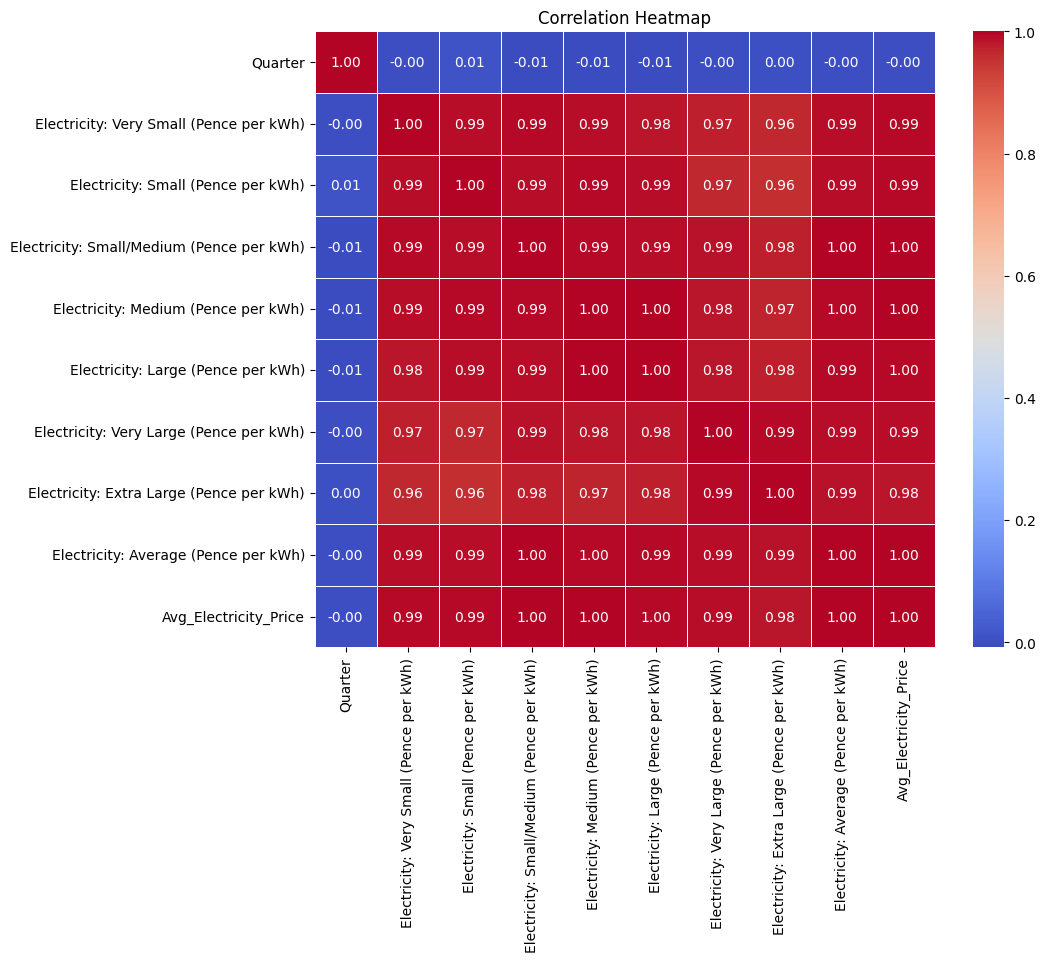

In [30]:
# Calculate the correlation matrix
corr_matrix = numeric_data.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Feature Information**

	1. Year: The year during which the pricing data was recorded (e.g., 2004, 2005).
	2.	Quarter: The quarter of the year (e.g., 1st, 2nd, 3rd, 4th), representing seasonal divisions.
	3.	Electricity: Very Small (Pence per kWh): The average electricity cost for very small-scale consumers, measured in pence per kilowatt-hour.
	4.	Electricity: Small (Pence per kWh): The average electricity cost for small-scale consumers, measured in pence per kilowatt-hour.
	5.	Electricity: Small/Medium (Pence per kWh): The average electricity cost for consumers in the small to medium consumption category, measured in pence per kilowatt-hour.
	6.	Electricity: Medium (Pence per kWh): The average electricity cost for medium-scale consumers, measured in pence per kilowatt-hour.
	7.	Electricity: Large (Pence per kWh): The average electricity cost for large-scale consumers, measured in pence per kilowatt-hour.
	8.	Electricity: Very Large (Pence per kWh): The average electricity cost for very large-scale consumers, measured in pence per kilowatt-hour.
	9.	Electricity: Extra Large (Pence per kWh): The average electricity cost for extra large-scale consumers, measured in pence per kilowatt-hour (contains some missing data).
	10.	Electricity: Average (Pence per kWh): The average electricity cost across all consumer categories, measured in pence per kilowatt-hour.

In [31]:
# proportion of count data on categorical columns
for col in categorical_data:
    print(raw_data[col].value_counts(normalize=True)*100)
    print('--------------------')

Year
2007    5.714286
2008    5.714286
2023    5.714286
2022    5.714286
2021    5.714286
2020    5.714286
2019    5.714286
2018    5.714286
2017    5.714286
2016    5.714286
2015    5.714286
2014    5.714286
2013    5.714286
2012    5.714286
2011    5.714286
2010    5.714286
2009    5.714286
2024    2.857143
Name: proportion, dtype: float64
--------------------


### 6) Exploratory Data Analysis
***6.1) Univariate Analysis***

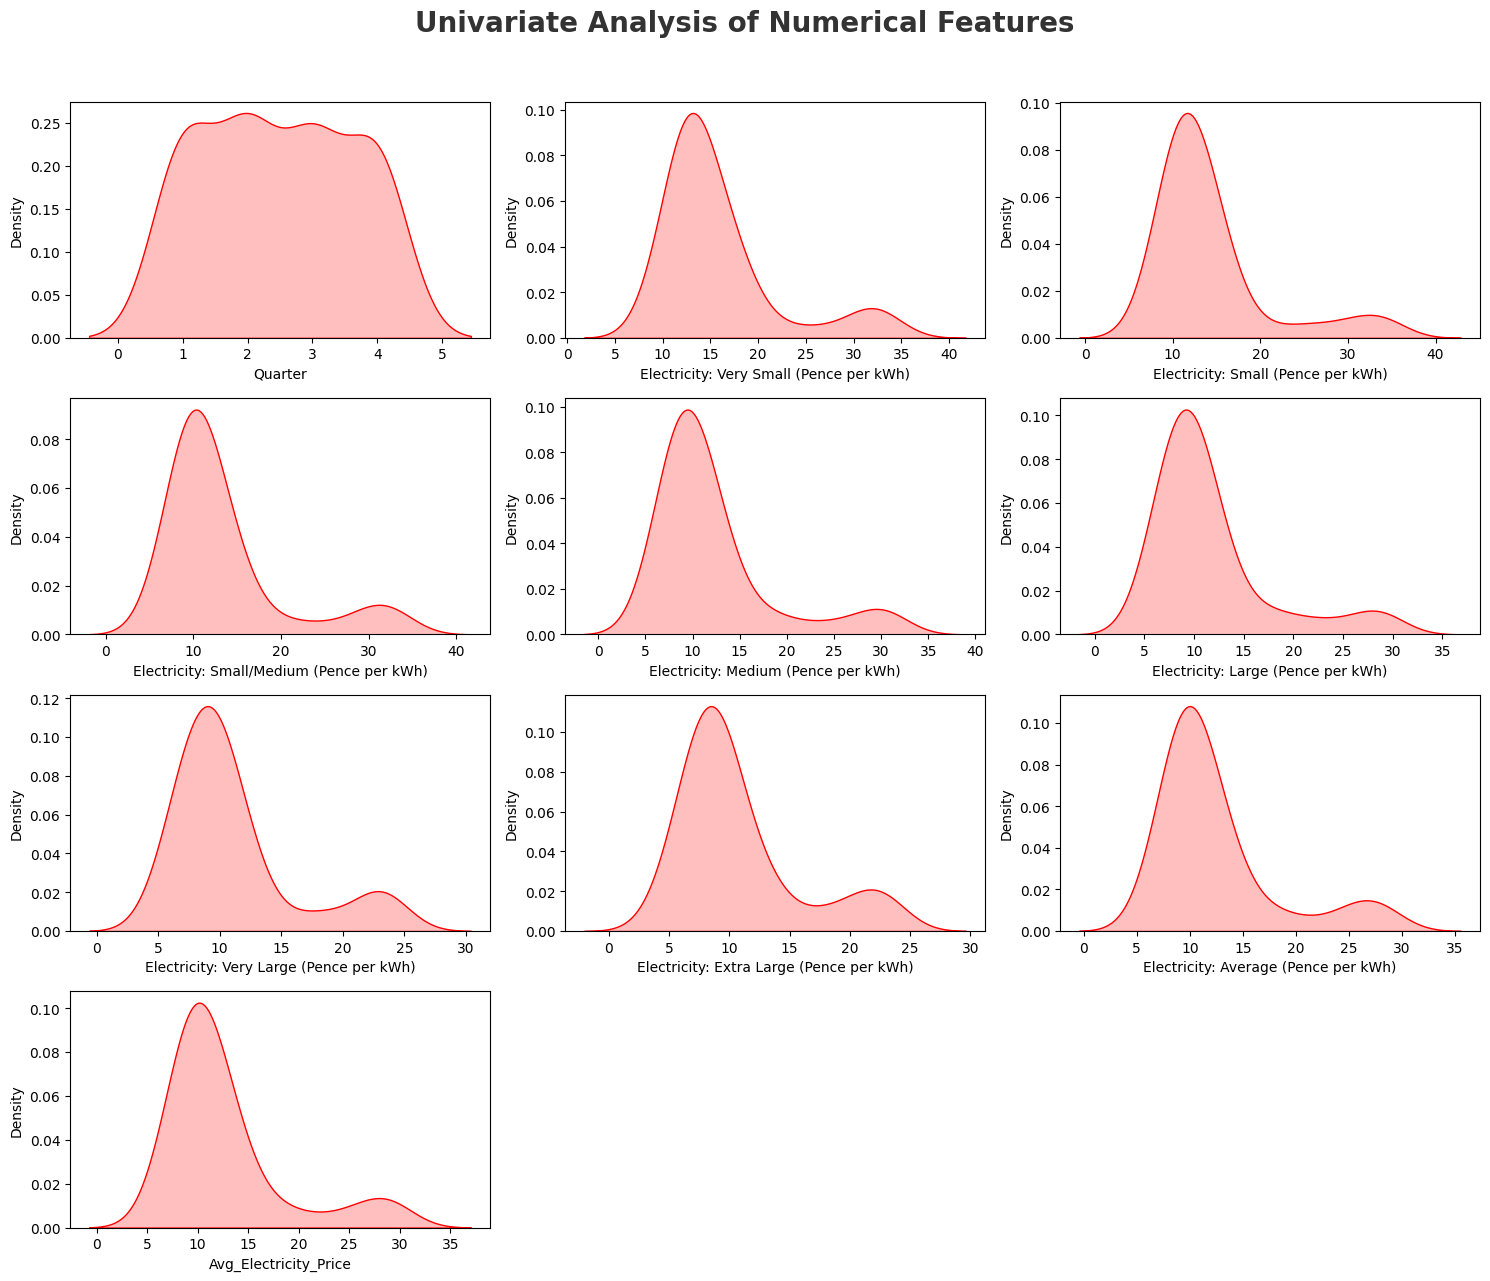

In [32]:
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.02)

for i, col in enumerate(numeric_data.columns, 1):
    plt.subplot(5, 3, i)  # Adjust grid size as needed (5 rows x 3 columns here)
    sns.kdeplot(x=numeric_data[col], fill=True, color='r')  # Replaced shade=True with fill=True
    plt.xlabel(col, fontsize=10)
    plt.tight_layout()

plt.show()

**Insights💡**

All numerical data points are all right skewed except Quarter

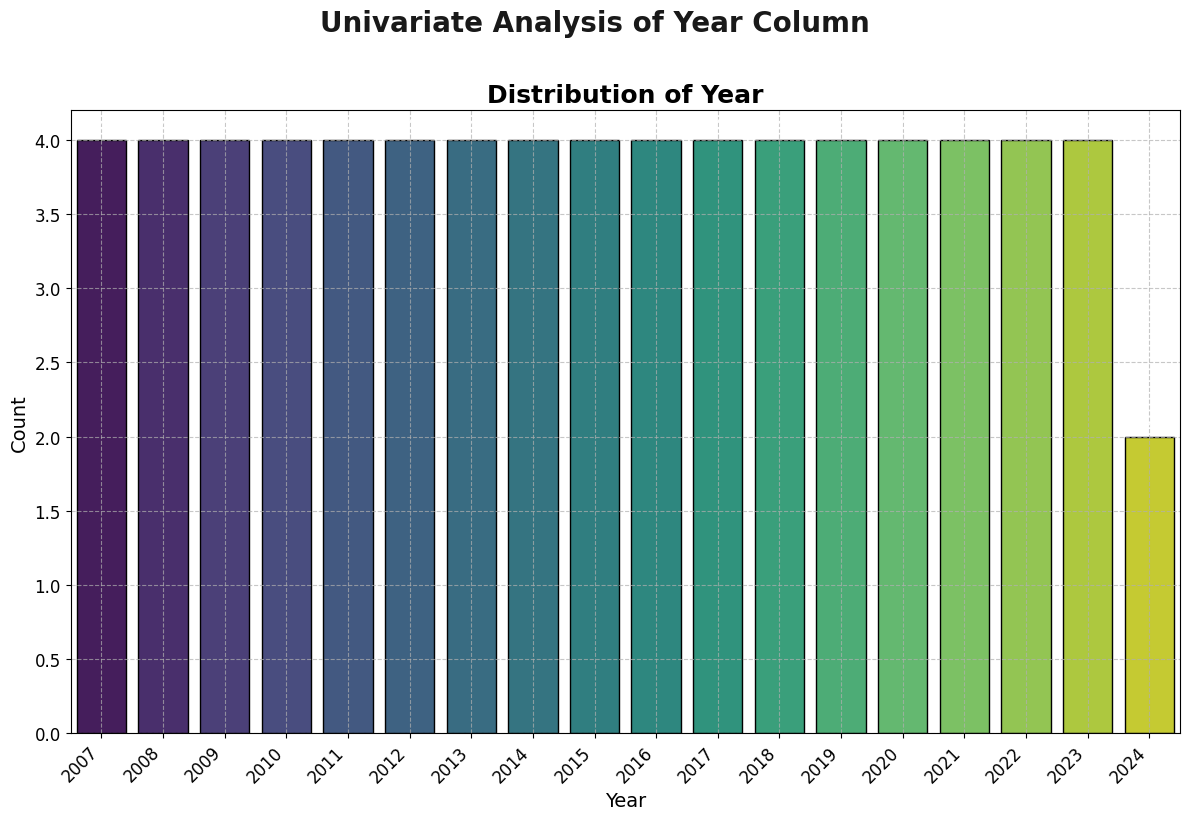

In [33]:
# Set up the figure
plt.figure(figsize=(12, 8))
plt.suptitle('Univariate Analysis of Year Column', fontsize=20, fontweight='bold', alpha=0.9, y=1.02)

# Use a color palette to give a refined look
sns.set_palette('muted')

# Create a countplot with better style and formatting
plt.subplot(1, 1, 1)  # A single plot for the Year column
sns.countplot(data=raw_data, x='Year', hue='Year', palette='viridis', edgecolor='black', legend=False)

# Enhance aesthetics
plt.title('Distribution of Year', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-ticks for better readability
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)  # Add grid for better visual alignment

# Optional: Adding value counts above bars for clarity
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       fontsize=12, color='white', 
                       xytext=(0, 10), textcoords='offset points')

# Adjust layout to avoid clipping
plt.tight_layout()

# Show the plot
plt.show()

**STAKEHOLDER QUESTIONS BEING ANSWERED**

1.) What is the trend in electricity prices over the years?

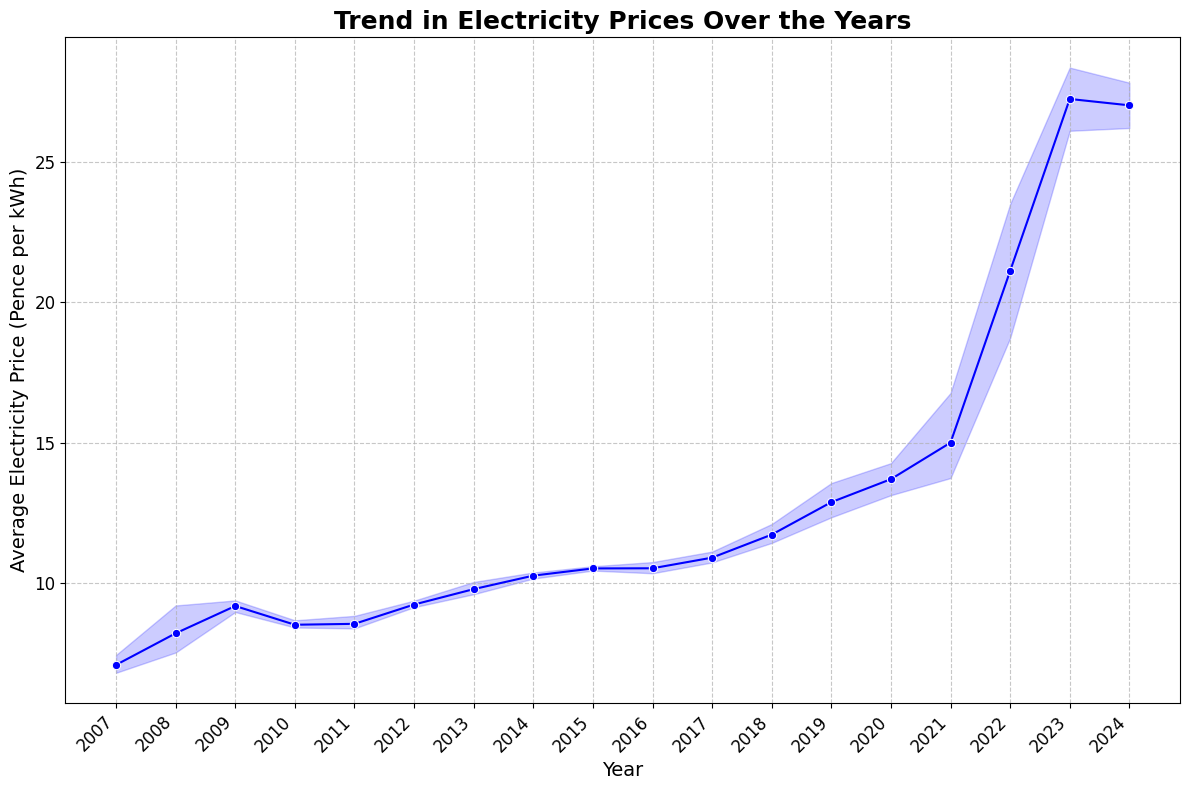

In [34]:
# Set up the figure
plt.figure(figsize=(12, 8))
plt.title('Trend in Electricity Prices Over the Years', fontsize=18, fontweight='bold')

# Plot the trend for Average Electricity Price over the years
sns.lineplot(data=raw_data, x='Year', y='Electricity: Average (Pence per kWh)', marker='o', color='b')

# Labels and formatting
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Electricity Price (Pence per kWh)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

2). Which year had the highest electricity prices on average?

In [35]:
# Find the year with the highest average electricity price
highest_price_year = raw_data.loc[raw_data['Electricity: Average (Pence per kWh)'].idxmax(), 'Year']
highest_price = raw_data['Electricity: Average (Pence per kWh)'].max()

print(f"The year with the highest average electricity price is {highest_price_year} with a price of {highest_price:.2f} pence per kWh.")

The year with the highest average electricity price is 2023 with a price of 28.39 pence per kWh.


3). What is the distribution of electricity prices in the ‘Extra Large’ category?

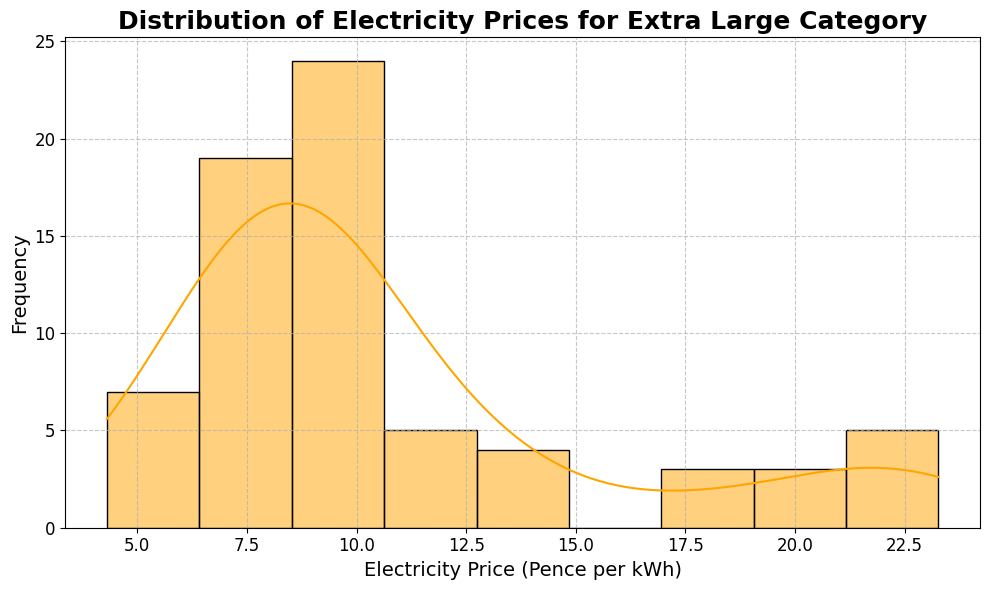

In [36]:
# Plot the distribution of 'Electricity: Extra Large' prices
plt.figure(figsize=(10, 6))
plt.title('Distribution of Electricity Prices for Extra Large Category', fontsize=18, fontweight='bold')

# Plot the distribution
sns.histplot(raw_data['Electricity: Extra Large (Pence per kWh)'], kde=True, color='orange')

# Labels and formatting
plt.xlabel('Electricity Price (Pence per kWh)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()